# Uvod v strojno učenje

Predmet smo začeli z obravnavo (hevrističnih) preiskovalnih algoritmov za reševanje problemov in igranje iger. Nato smo prešli na problem zadoščanja omejitvam, kjer poleg preiskovanja pomembno vlogo igra sklepanje, saj nam pomaga prioritetizirati različne prireditve vrednosti spremenljivkam in tako hitreje priti do rešitve. V nadaljevanju smo sklepanje formalizirali najprej v propozicijski logiki, nato še v logiki prvega reda. Zatem smo obravnavali še sklepanje v negotovosti, kjer ne sklepamo več le o tem, ali nekaj velja ali ne, temveč računamo verjetnosti različnih posledic in predpostavk. Pri vseh teh pristopih ima pomembno vlogo baza znanja.

V sedemdesetih letih 20. stoletja so raziskovalci umetne inteligence ugotovili, da je ročna gradnja baze znanja pogosto izjemno zahtevna, včasih pa celo praktično nemogoča. Ta problem je Edward Feigenbaum poimenoval ozko grlo formalizacije znanja (_knowledge formalization bottleneck_). Ena ključnih idej, ki se je pojavila kot odgovor na to težavo, je bila, da bi znanje oziroma model odločanja gradili iz primerov odločitev ali sklepov, ki so jih v praksi sprejeli eksperti. Algoritmi, ki omogočajo takšno gradnjo modelov iz podatkov, so postali znani kot algoritmi strojnega učenja. V nadaljevanju predavanj bomo torej spoznali pomembno podpodročje umetne inteligence, strojno učenje.

Strojno učenje preučuje, kako iz podatkov samodejno zgraditi modele, ki znajo pojasnjevati opažene pojave, prepoznavati uporabne vzorce in napovedovati vrednosti, ki jih še ne poznamo. V teh zapiskih najprej uvedemo osnovne pojme in formalne definicije za nadzorovano strojno učenje, nato osvetlimo dve osrednji težavi strojnega učenja, na koncu pa spoznamo dve preprosti, a pomembni metodi: Naivni Bayes za klasifikacijo in metodo najbližjih sosedov.

Spomnimo se še motivacijskega primera iz uvodnih predavanj, ki povzema znamenito analizo epidemije kolere v Londonu leta 1854. John Snow je zbral podatke o smrtnih primerih in njihovih lokacijah ter jih povezal z lokacijami vodnih črpalk. V podatkih je prepoznal vzorec: veliko smrtnih primerov je bilo skoncentriranih v bližini črpalke na ulici Broad. Na tej osnovi je oblikoval hipotezo, da je okužba povezana z vodo iz te črpalke, ter predlagal ukrep, zaprtje črpalke. Ta primer nazorno pokaže tri tipične cilje strojnega učenja:

- iskanje zanimivih vzorcev v podatkih,
- gradnjo napovednih modelov in
- podporo odločanju in ukrepanju inteligentnega agenta.

Pomembna poanta je, da podatki sami po sebi še niso znanje. Uporabni postanejo šele, ko iz njih izluščimo strukturo, ki nam pomaga razumeti pojav ali napovedati, kaj se bo zgodilo v novi situaciji.

Predavanje podaja uvod v strojno učenje, kakršnega obravnavata uvodni poglavji _1 Introduction_ in _2 Statistical Learning_ učbenika {cite}`james2023islrp`. Algoritem za nadzorovano strojno učenje Naivni Bayes je predstavljen v razdelku _4.4.4 Naive Bayes_ istega učbenika.

## Formalne definicije za nadzorovano strojno učenje

Strojno učenje preučuje algoritme, ki na osnovi izkušenj (angl. _experience_, $E$) izboljšujejo svojo uspešnost (angl. _performance_, $P$) pri reševanju podane naloge (angl. _task_, $T$). V nadzorovanem strojnem učenju (angl. _supervised machine learning_) je naloga napovedovanje vrednosti ciljne spremenljivke iz podanih vrednosti napovednih spremenljivk. Izkušnje predstavljajo učni primeri, mera uspešnosti pa je običajno napovedna točnost oziroma napaka modela. Učenje imenujemo nadzorovano zato, ker vsak učni primer poleg vrednosti napovednih spremenljivk vsebuje tudi opazovano vrednost ciljne spremenljivke, kar nam omogoča merjenje napake napovednega modela.

Zapišimo zdaj osnovne pojme bolj formalno.

```{prf:definition} Podatkovna množica (angl. _data set_) za nadzorovano učenje

Naj bo $\boldsymbol{X} = \left< X_1, X_2, \dots, X_p \right>$ urejena $p$-terica _napovednih spremenljivk_ z domenami $D_{X_1}, D_{X_2}, \dots, D_{X_p}$ in naj bo $Y$ _ciljna spremenljivka_ z domeno $D_Y$.

_Primer_ je urejena dvojica $e = \left< \boldsymbol{x}, y \right>$, kjer je
$\boldsymbol{x} = \left< x_1, x_2, \dots, x_p \right> \in D_{X_1} \times D_{X_2} \times \dots \times D_{X_p}$ vektor opazovanih vrednosti napovednih spremenljivk, $y \in D_Y$ pa opazovana vrednost ciljne spremenljivke.

_Podatkovna množica_ je končna množica primerov
$$
    S \subseteq D_{X_1} \times D_{X_2} \times \dots \times D_{X_p} \times D_Y.
$$
```

Pri strojnem učenju razlikujemo dva osnovna tipa spremenljivk. Domena _numerične spremenljivke_ je običajno množica realnih števil, njene vrednosti pa so urejene. Domena _diskretne spremenljivke_ je končna množica možnih vrednosti, ki praviloma niso urejene. _Binarna spremenljivka_ je diskretna spremenljivka, ki ima natanko dve možni vrednosti.

V praksi in pri implementaciji algoritmov nadzorovanega strojnega učenja podatkovno množico pogosto obravnavamo kot seznam oziroma večmnožico primerov, saj se lahko isti primer v podatkih pojavi več kot enkrat.

Zgled naloge napovedovanja iz vsakdanjega življenja je napovedovanje vremena za naslednji dan. V tem primeru lahko kot napovedne spremenljivke uporabimo _zračni tlak_ ($X_1$), _relativno vlažnost_ ($X_2$) in _hitrost vetra_ ($X_3$), izmerjene na današnji dan. Ciljna spremenljivka opisuje vreme naslednji dan. Lahko je, na primer, binarna spremenljivka _dež_ z vrednostma $\{\text{da}, \text{ne}\}$, ki napove, ali bo naslednji dan deževalo. Lahko pa je numerična spremenljivka _temperatura_, ki napove temperaturo zraka naslednjega dne. Iz istega nabora napovednih spremenljivk lahko torej zgradimo dve različni podatkovni množici: eno za klasifikacijo padavin in drugo za regresijsko napoved temperature.

Premisli, kakšni so tipi posameznih spremenljivk v tem primeru.

```{prf:definition} Napovedni model (angl. _predictive model_)

_Napovedni model_ je preslikava
$$
    m \colon D_{X_1} \times D_{X_2} \times \dots \times D_{X_p} \to D_Y,
$$
ki vektorju vrednosti napovednih spremenljivk $\boldsymbol{x}$ priredi napoved vrednosti ciljne spremenljivke $\hat{y} = m(\boldsymbol{x})$.
```

Ločimo dva osnovna tipa napovednih modelov: _regresijski model_ napoveduje vrednosti _numerične_ ciljne spremenljivke, _klasifikacijski model_ pa napoveduje vrednosti _diskretne_ ciljne spremenljivke. Model za napovedovanje temperature zraka iz zgornjega primera je regresijski, model za napovedovanje padavin pa klasifikacijski.

Za merjenje uspešnosti modela oziroma njegove napake moramo najprej definirati funkcijo izgube.

```{prf:definition} Funkcija izgube (angl. _loss function_)

_Funkcija izgube_ je preslikava
$$
L \colon D_Y \times D_Y \to \mathbb{R}_{\geq 0}.
$$
Za opazovano vrednost $y$ in napoved $\hat{y}$ vrednost $L(y, \hat{y})$ meri napako napovedi.
```

Običajno zahtevamo, da je $L(y, \hat{y}) = 0$ natanko tedaj, ko je napoved pravilna (velja torej $y = \hat{y}$), sicer pa je izguba pozitivna. Primer pogosto uporabljene funkcije izgube za regresijo je _kvadratna izguba_ (angl. _square error, SE_):
$$
L_{SE}(y, \hat{y}) = (y - \hat{y})^2.
$$
Primer funkcije izgube za klasifikacijo je _izguba 0-1_:
$$
L_{01}(y, \hat{y}) =
\begin{cases}
0, & y = \hat{y}, \\
1, & y \neq \hat{y}.
\end{cases}
$$

S funkcijo izgube $L$ lahko napako modela $m$ na podatkovni množici $S$ izračunamo kot povprečje izgube po vseh primerih iz $S$:
$$
\mathrm{Error}(m, S) = \frac{1}{|S|} \sum_{\left< \boldsymbol{x}, y \right> \in S} L(y, m(\boldsymbol{x})).
$$

```{prf:definition} Algoritem za nadzorovano strojno učenje

Naj bo $\mathcal{D}$ prostor dopustnih podatkovnih množic in $\mathcal{M}$ prostor dopustnih napovednih modelov.

_Algoritem za nadzorovano strojno učenje_ je preslikava
$$
A \colon \mathcal{D} \to \mathcal{M},
$$
ki podani podatkovni množici primerov $S$ priredi napovedni model $m = A(S)$.
```

Naloga algoritma je torej, da iz učnih primerov zgradi model, ki bo znal dobro napovedovati ciljno spremenljivko tudi za nove primere. Pri tem opazujemo dve ključni lastnosti napovednega modela, ki sta tesno povezani z njegovo napako:
- _točnost_ na učnih podatkih,
- _splošnost_ oziroma sposobnost, da model dobro deluje tudi na novih podatkih.

Dober model je _hkrati_ čim bolj točen (angl. _accurate_) in čim bolj splošen (angl. _general_). Za ocenjevanje točnosti modela $m$ izmerimo njegovo napako na učni množici $\mathrm{Error}(m, S)$. Za ocenjevanje splošnosti modela običajno uporabimo testno množico $S_{\textrm{test}}$, ki ni bila na voljo med učenjem. Učna in testna množica sta disjunktni, torej velja $S \cap S_{\textrm{test}} = \emptyset$. Da se izognemo dvoumnosti, učno množico pogosto označimo z $S_{\textrm{train}}$.

Temeljni problem v strojnem učenju je prav v tem, da model ne sme biti le dober opis učnih podatkov (zgolj _točen_), temveč mora zajeti dovolj splošne zakonitosti, da je uporaben tudi na podatkih izven učne podatkovne množice (torej, _splošen_). Več o tem v naslednjem razdelku.

## Ključni problem nadzorovanega strojnega učenja

Prvi problem, ki ga srečujemo pri nadzorovanem strojnem učenju, je, da točen model običajno ni dovolj splošen. Če model preveč natančno sledi učnim podatkom, se lahko poleg splošnih pravil in zakonitosti razmerij med ciljno in napovednimi spremenljivkami nauči tudi naključnih posebnosti v podatkih, ki nastanejo na primer zaradi šuma pri merjenju in opazovanju. Tak model ima torej zelo majhno napako na učni množici (je točen), a slabo deluje na novih primerih (ni splošen). Temu pojavu rečemo _pretirano prileganje_ učnim podatkom ali, krajše, _preprileganje_ (angl. _overfitting_).

Nasprotna težava je _podprileganje_ podatkom (angl. _underfitting_). Takrat je model preveč enostaven, da bi sploh zajel osnovne zakonitosti razmerij med ciljno in napovednimi spremenljivkami, zato je slab že na učni množici (ni točen).

Zato je izbira napovednega modela za podane podatke zahtevna naloga, ki terja primerjavo različnih modelov, naučenih z različnimi algoritmi strojnega učenja in različnimi nastavitvami teh algoritmov. Tipičen cilj pri izbiri modela je poiskati ravnotežje med obema skrajnostma: model mora biti dovolj prilagodljiv, da ujame pomembne zakonitosti, a ne tako prilagodljiv, da bi si preprosto zapomnil vse učne podatke.

V ta namen potrebujemo tudi dobro definirane mere napovedne zmogljivosti modelov, ki zajamejo tako njihovo točnost kot tudi splošnost in jih bomo spoznali na naslednjih predavanjih. V nadaljevanju tega predavanja bomo spoznali dva preprosta algoritma strojnega učenja, Naivni Bayes in metodo najbližjih sosedov.

## Naivni Bayes za klasifikacijo

Naivni Bayes je preprost algoritem za nadzorovano učenje klasifikacijskih modelov. Temelji na Bayesovi formuli, ki smo jo spoznali na prejšnjem predavanju o Bayesovih mrežah, in na predpostavki o medsebojni pogojni neodvisnosti napovednih spremenljivk. Uporaben je predvsem takrat, ko želimo iz več _diskretnih napovednih_ spremenljivk napovedati vrednost diskretne ciljne spremenljivke.

Naj bo ciljna spremenljivka $Y$ diskretna in naj bodo $X_1, X_2, \dots, X_p$ napovedne spremenljivke. Za podani primer $\boldsymbol{x} = \left< x_1, x_2, \dots, x_p \right>$ želimo izračunati posteriorno verjetnost vrednosti $y$ ciljne spremenljivke $Y$:
$$
P(Y=y \mid X_1=x_1, X_2=x_2, \dots, X_p=x_p).
$$
Po Bayesovi formuli velja
$$
P(Y=y \mid X_1=x_1, \dots, X_p=x_p) = \frac{P(X_1=x_1 \land \dots \land X_p=x_p \mid Y=y) P(Y=y)}{P(X_1=x_1 \land \dots \land X_p=x_p)}.
$$
Ker je imenovalec enak za vse vrednosti ciljne spremenljivke, za klasifikacijo zadošča primerjati količine
$$
P(X_1=x_1 \land X_2=x_2 \land \dots \land X_p=x_p \mid Y=y) P(Y=y)
$$
za različne vrednosti $y$ ciljne spremenljivke $Y$.

Težava pri uporabi te formule je, da je skupno verjetnost $P(X_1=x_1 \land X_2=x_2 \land \dots \land X_p=x_p \mid Y=y)$ v splošnem težko oceniti, saj bi morali poznati oziroma dobro oceniti verjetnosti vseh kombinacij vrednosti napovednih spremenljivk. Naivni Bayes uvede poenostavitveno predpostavko:

> Če poznamo vrednost ciljne spremenljivke $Y$, so napovedne spremenljivke $X_1, X_2, \dots, X_p$ med seboj pogojno neodvisne.

Tedaj lahko zapišemo
$$
P(X_1=x_1 \land X_2=x_2 \land \dots \land X_p=x_p \mid Y=y) = \prod_{i=1}^p P(X_i=x_i \mid Y=y),
$$
zato klasifikacijsko pravilo postane
$$
\hat{y} = \arg\max_{y \in D_Y} P(Y=y) \prod_{i=1}^p P(X_i=x_i \mid Y=y).
$$

Model, ki ga dobimo z Naivnim Bayesom, torej napove tisto vrednost $y \in D_Y$ ciljne spremenljivke $Y$, za katero je izraz
$$
P(Y=y) \prod_{i=1}^p P(X_i=x_i \mid Y=y)
$$
največji.

Algoritem gradi model tako, da ocenjuje dve vrsti verjetnosti:
- _a priori_ verjetnosti za različne vrednosti ciljne spremenljivke $P(Y=y)$,
- pogojne verjetnosti vrednosti napovednih spremenljivk za posamezne vrednosti ciljne spremenljivke $P(X_i=x_i \mid Y=y)$.

Te verjetnosti algoritem lahko oceni neposredno iz učne množice s štetjem frekvenc različnih vrednosti napovednih spremenljivk za podano vrednost ciljne spremenljivke. Pri diskretnih napovednih spremenljivkah je to zelo preprosto. Če so napovedne spremenljivke numerične, pogosto predpostavimo še neko parametrično obliko porazdelitve, na primer normalno porazdelitev znotraj posameznega razreda in iz učne množice ocenimo vrednosti njenih parametrov (pri normalni porazdelitvi torej ocenimo povprečje in varianco).

Glavne prednosti algoritma Naivni Bayes so njegova zelo enostavna implementacija, hitro učenje (štetje vrednosti) in hitro napovedovanje (produkt nekaj ocen verjetnosti, izračunanih na učni množici). Z algoritmom dobimo modele, ki imajo presenetljivo dobro napovedno zmogljivost (točnost in splošnost) tudi v primeru velikega števila napovednih spremenljivk, kar srečamo na primer pri klasifikaciji besedil v tematska področja.

Glavna slabost algoritma je seveda naivna predpostavka pogojne neodvisnosti napovednih spremenljivk, ki v praksi pogosto ne velja. Kljub temu je metoda pogosto zelo uporabna, ker za dobro klasifikacijo ni nujno, da so ocenjene verjetnosti popolnoma natančne; pogosto zadostuje že to, da model pravilno razvrsti vrednosti ciljne spremenljivke po njihovi ocenjeni verjetnosti.

Naivni Bayes je zato zelo dober prvi orientacijski model: je hiter, razložljiv in nam pogosto poda presenetljivo močen osnovni model, s katerim potem lahko primerjamo zahtevnejše metode in napovedne modele.

## Metoda najbližjih sosedov

Metoda najbližjih sosedov (_nearest neighbors, NN_) je še en zelo preprost algoritem za nadzorovano strojno učenje. Posebej uporabna je v primerih, ko so napovedne spremenljivke numerične, oziroma kadar lahko med primeri smiselno izračunamo razdaljo. Z algoritmom lahko obravnavamo tako klasifikacijske kot regresijske podatkovne množice. Ključna ideja algoritma je opazovanje lokalne okolice (soseščine) podanega primera. Za podan nov primer pogledamo nekaj njemu najbolj podobnih primerov iz učne množice in iz njih izračunamo napoved.

Da lahko opazujemo lokalno okolico primera, potrebujemo mero razdalje v prostoru napovednih spremenljivk $D_{X_1} \times D_{X_2} \times \dots \times D_{X_p}$. Če predpostavimo, da so vse napovedne spremenljivke numerične, je to vektorski prostor $\mathbb{R}^p$. V tem prostoru poznamo vsaj dve pogosti meri razdalje med primeri. Evklidska razdalja meri dolžino daljice, ki povezuje dve podani točki v tem prostoru:
$$
    d(\boldsymbol{u}, \boldsymbol{v}) = \sqrt{\sum_{i=1}^p (u_i - v_i)^2},
$$
kjer sta $u_i$ in $v_i$ $i$-ti komponenti vektorjev $\boldsymbol{u}$ in $\boldsymbol{v}$. Manhattanska razdalja je možna alternativa, ki meri razdaljo vzdolž koordinatnih osi vektorskega prostora:
$$
    d(\boldsymbol{u}, \boldsymbol{v}) = \sum_{i=1}^p |u_i - v_i|.
$$

Če poznamo mero razdalje med primeri, lahko definiramo soseščino primera.

```{prf:definition} Soseščina primera $\left< \boldsymbol{x}_0, \cdot \right>$ velikosti $k$ v učni množici $S$

Naj bo podan primer $\left< \boldsymbol{x}_0, \cdot \right>$, $\boldsymbol{x}_0 \in \mathbb{R}^p$ z neznano vrednostjo ciljne spremenljivke, učna množica primerov $S$ in mera razdalje $d \colon \mathbb{R}^p \times \mathbb{R}^p \to \mathbb{R}_{\geq 0}$.

_Soseščina primera_ $\left< \boldsymbol{x}_0, \cdot \right>$ velikosti $k$ je množica $k$ primerov iz množice $S$, ki so glede na mero razdalje $d$ najmanj oddaljeni od primera $\left< \boldsymbol{x}_0, \cdot \right>$. Označimo jo z $\mathcal{S}(\left< \boldsymbol{x}_0, \cdot \right>, S, k)$:
- $\mathcal{S}(\left< \boldsymbol{x}_0, \cdot \right>, S, k) \subseteq S$,
- $|\mathcal{S}(\left< \boldsymbol{x}_0, \cdot \right>, S, k)| = k$,
- za vsak $\left< \boldsymbol{x}_1, y_1 \right> \in \mathcal{S}(\left< \boldsymbol{x}_0, \cdot \right>, S, k)$ in vsak $\left< \boldsymbol{x}_2, y_2 \right> \in S \setminus \mathcal{S}(\left< \boldsymbol{x}_0, \cdot \right>, S, k)$ velja $d(\boldsymbol{x}_1, \boldsymbol{x}_0) \leq d(\boldsymbol{x}_2, \boldsymbol{x}_0)$.
```

Algoritem najbližjih sosedov za podan primer $\left< \boldsymbol{x}_0, \cdot \right>$ in velikost soseščine $k$ najprej poišče soseščino $\mathcal{S}(\left< \boldsymbol{x}_0, \cdot \right>, S, k)$ primerov iz učne množice $S$, nato pa iz vrednosti ciljnih spremenljivk teh primerov izračuna napoved.

1. V primeru regresije, povprečno vrednost ciljne spremenljivke za primere v soseščini:
$$
    m(\boldsymbol{x}_0) = \frac{1}{k} \sum_{\left< \boldsymbol{x}, y \right> \in \mathcal{S}(\left< \boldsymbol{x}_0, \cdot \right>, S, k)} y.
$$

1. V primeru klasifikacije, modus vrednosti ciljne spremenljivke za primere v soseščini:
$$
    m(\boldsymbol{x}_0) = \arg\max_{y \in D_Y} |\{ \left< \boldsymbol{x}', y' \right> \in \mathcal{S}(\left< \boldsymbol{x}_0, \cdot \right>, S, k) \colon y' = y \}|,
$$
torej vrednost ciljne spremenljivke $y$, ki se največkrat pojavi v primerih iz soseščine.

Pri uporabi metode najbližjih sosedov ne smemo pozabiti poskrbeti, da vrednosti napovednih spremenljivk normaliziramo tako, da imajo primerljive skale, na primer podobna povprečja in variance ali enake razpone možnih vrednosti. Če tega ne naredimo, lahko pri računanju razdalje napovedna spremenljivka z večjim številskim razponom neupravičeno prevlada nad ostalimi.

Parameter $k$ določa, koliko sosedov iz učne množice upošteva algoritem pri napovedovanju. Njegov vpliv je neposredno povezan s pretiranim prileganjem:

- pri $k=1$ se model močno prilagodi učni množici in je zelo občutljiv na šum in spremembe v podatkih,
- pri večjem $k$ postane model bolj gladek in stabilen,
- če je $k$ prevelik, lahko model izgubi vpogled v lokalno okolico podanega primera, računa povprečje velikega števila učnih primerov in se zato začne podprilegati (premalo prilagajati učnim podatkom).

Izbira $k$ je zato tipičen primer kompromisa med točnostjo in splošnostjo modela, ki ga bomo opazovali tudi pri drugih algoritmih strojnega učenja v nadaljevanju predavanj.

## Osnovna uporaba paketa `scikit-learn`

V tem razdelku bomo za praktično uporabo metode najbližjih sosedov uporabili Pythonov paket [`scikit-learn`](https://scikit-learn.org/). Paket vsebuje implementacije številnih algoritmov strojnega učenja ter orodja za pripravo podatkov, učenje modelov in vrednotenje njihove napovedne zmogljivosti.

Kot ilustrativen primer bomo uporabili vgrajeno podatkovno množico `iris`, ki vsebuje 150 primerov cvetlic perunike iz treh različnih razredov, pri čemer je vsak primer opisan s štirimi napovednimi spremenljivkami. Zaradi lažje vizualizacije bomo obdržali le prvi dve napovedni spremenljivki, tako da bomo lahko primere in odločitvene meje prikazali v ravnini. Nato bomo naučili klasifikacijski model po metodi najbližjih sosedov za več različnih vrednosti parametra $k$ (velikosti soseščine). Za vsako vrednost $k$ bomo na grafu prikazali odločitvene meje med različnimi napovedmi modela in učne primere.

Začnimo z nalaganjem potrebnih knjižnic. Podatkovne množice so v paketu `scikit-learn` pravzaprav podatkovne tabele, ki jih najlažje obdelujemo s funkcijami paketa `numpy`. Za risanje grafov bomo uporabljali funkcije paketa `matplotlib`. Iz paketa `scikit-learn` (pozor, njegovo ime v Pythonu je `sklearn`) naložimo funkciji za podatkovno množico `iris` in razred `KNeighborsClassifier`, ki omogoča učenje in uporabo klasifikacijskih modelov z metodo najbližjih sosedov.

In [21]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier


Nato naložimo podatkovno množico `iris`, obdržimo zgolj prvi dve napovedni spremenljivki in izpišemo osnovne lastnosti podatkovne množice.

In [22]:
iris = load_iris() # Naložimo podatkovno mnozico iris
X = iris.data[:, :2] # Obdržimo samo prvi dve napovedni spremenljivki
y = iris.target

print('Oblika podatkovne mnozice (primeri, napovedne spremenljivke):', X.shape)
print('Vrednosti ciljne spremenljivke:', iris.target_names)
print('Napovedni spremenljivki:', iris.feature_names[:2])

Oblika podatkovne mnozice (primeri, napovedne spremenljivke): (150, 2)
Vrednosti ciljne spremenljivke: ['setosa' 'versicolor' 'virginica']
Napovedni spremenljivki: ['sepal length (cm)', 'sepal width (cm)']


Zdaj definiramo funkcijo, ki na podano platno nariše graf odločitvenih mej med podmnožicami podatkovnega prostora z različnimi napovedanimi vrednostmi ciljne spremenljivke. Funkcija se najprej nauči model tako, da ustvari nov objekt razreda `KNeighborsClassifier` (podamo vrednost parametra $k$) in nato z uporabo metode `fit` nauči model na podatkovni množici, podani s parom `(X, y)`, kjer je `X` matrika vrednosti napovednih spremenljivk, `y` pa vektor vrednosti ciljne spremenljivke.

Nato pripravimo graf tako, da pripravimo mrežo točk (velikosti $300x300$), ki se razteza skozi prostor napovednih spremenljivk. Za vsako točko napovemo vrednost ciljne spremenljivke, ki določi barvo te točke. S takim barvanjem točk vizualiziramo jasne odločitvene meje med različnimi napovedmi. Na isti graf narišemo še primere (s točkami pobarvanimi na osnovi vrednosti ciljne spremenljivke za posamezen primer). Na koncu graf opremimo z oznakami osi in naslovom.

In [23]:
# Pomožna funkcija za prikaz odločitvenih mej algoritma najbližjih sosedov
#  platno: matplotlibovo platno, na katerem bomo narisali graf
#  X: matrika vrednosti napovednih spremenljivk v učni množici
#  y: vektor vrednosti ciljne spremenljivke v učni množici
#  k: velikost soseščine za algoritem najbližjih sosedov
#  X_imena: imena napovednih spremenljivk
#  y_vrednosti: vrednosti ciljne spremenljivke

def knn_odlocitvene_meje(platno, X, y, k, X_imena, y_vrednosti):

    # naučimo model algoritma najbližjih sosedov na učni množici
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X, y)

    # ustvarimo mrežo točk, ki pokriva območje, kjer se nahajajo podatki
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300),
    )

    # napovemo razred za vsako točko v mreži
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)

    # narišemo podatke in odločitvene meje
    graf = platno.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k')
    platno.contourf(
        xx,
        yy,
        zz,
        alpha=0.3,
        levels=np.arange(len(y_vrednosti) + 1) - 0.5,
        cmap='viridis',
    )

    # nastavimo oznake osi in naslov grafa
    platno.set_title(f'k = {k}')
    platno.set_xlabel(X_imena[0])
    platno.set_ylabel(X_imena[1])

    return graf

Zdaj lahko uporabimo funkcijo za primerjavo napovednih modelov, ki jih dobimo s štirimi različnimi vrednostmi parametra $k$ (velikost soseščine), 1, 5, 10 in 50. Štiri grafe sestavimo v eno sliko z ustreznim naslovom in legendo za barve, ki ustrezajo vrednostim ciljne spremenljivke.

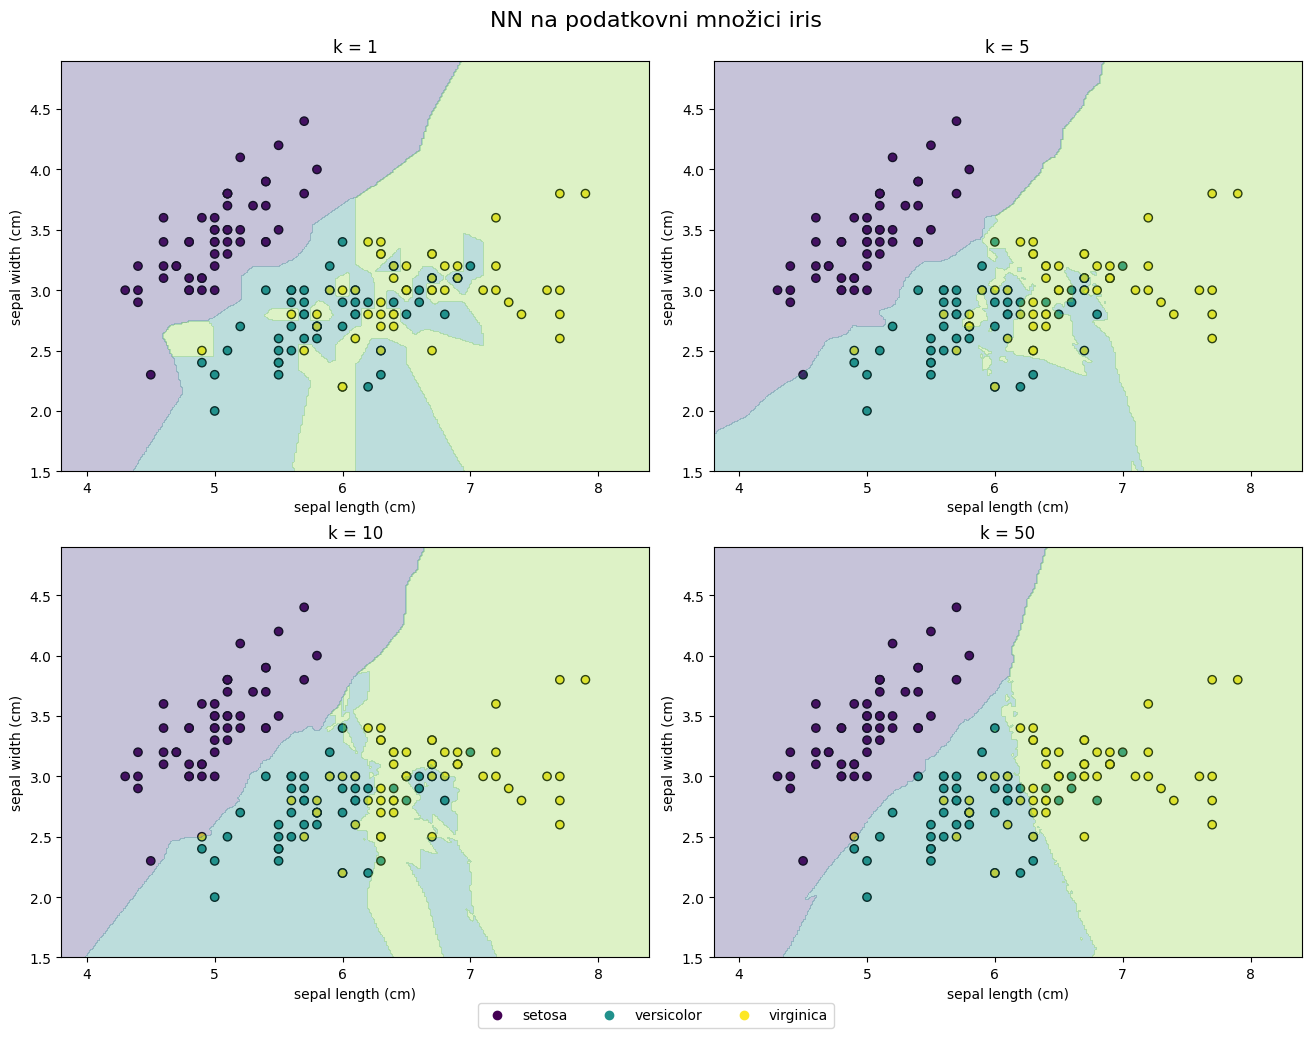

In [31]:
k_values = [1, 5, 10, 50]

# ustvarimo 4 grafe, ki prikazujejo odločitvene meje algoritma najbližjih sosedov za različne vrednosti k
slika, osi = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)
osi = osi.ravel()
for platno, k in zip(osi, k_values):
    graf = knn_odlocitvene_meje(
        platno,
        X,
        y,
        k,
        iris.feature_names[:2],
        iris.target_names
    )

# dodamo legendo in naslov celotne slike
rocke, _ = graf.legend_elements()
slika.legend(rocke, iris.target_names, loc='lower center', bbox_to_anchor=(0.5, -0.03), ncol=3)
slika.suptitle('k-NN na podatkovni množici iris', fontsize=16)
plt.show()

Na zgornjih slikah vidimo, kako izbira parametra $k$ vpliva na obliko in kompleksnost odločitvenih mej. Pri $k=1$ se model zelo tesno prilagodi učnim primerom, zato so meje med različnimi vrednostmi ciljne spremenljivke razmeroma razgibane in ponekod zajemajo vsak učni primer posebej. Z večanjem $k$ postajajo odločitvene regije bolj gladke, model pa manj občutljiv na vrednosti ciljne spremenljivke za posamezne učne primere. V tem primeru uporabljamo samo učne primere; z vrednotenjem na ločeni, testni podatkovni množici se bomo ukvarjali v nadaljevanju predavanj.

# Naloga za bonus točke

1. (5 točk, rok za oddajo: 20. april) Za podatkovno množico [`mushroom`](https://www.kaggle.com/datasets/uciml/mushroom-classification) zgradi klasifikacijski model, ki napove užitnost gob na osnovi njihovega opisa (vsaka goba v podatkovni množici je opisana z 22 napovednimi spremenljivkami), z uporabo algoritma Naivni Bayes. Pri tem lahko algoritem implementiraš sam_a ali pa uporabiš njegovo ustrezno implementacijo v paketu `scikit-learn`.
<br/><br/>
